In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Reading bleaching rate data

In [21]:
identifiers = ['1e1', '1e2', '1e3', '1e4']
bleaching_times_all_A = []
fingerprints_all_A = []
total_photons_A = []
ON_periods_A_frames = []
OFF_periods_A_frames = []

for _ in identifiers:
    fingerprints_all_A.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    total_photons_A.append([])
    ON_periods_A_frames.append([])
    OFF_periods_A_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\bl_rate"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_A.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_A[identifiers.index(id)] += data.sum(axis=1)
                total_photons_A[identifiers.index(id)] += data.sum(axis=0).values.tolist()
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    ON_periods_A_frames[identifiers.index(id)] += blinks.on_periods.tolist()
                    OFF_periods_A_frames[identifiers.index(id)] += blinks.off_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_A):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_A[i] = fingerprint

In [3]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_A = []
for fingerprint in fingerprints_all_A:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_A.append([param.value for param in result.params.values()])

### Reading ON to OFF data

In [2]:
identifiers = ['red1', 'red01', 'red005', 'red001']
bleaching_times_all_B = []
fingerprints_all_B = []
total_photons_B = []
ON_periods_B_frames = []
OFF_periods_B_frames = []

for _ in identifiers:
    fingerprints_all_B.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    total_photons_B.append([])
    ON_periods_B_frames.append([])
    OFF_periods_B_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_prob"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_B.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_B[identifiers.index(id)] += data.sum(axis=1)
                total_photons_B[identifiers.index(id)] += data.sum(axis=0).values.tolist()
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    ON_periods_B_frames[identifiers.index(id)] += blinks.on_periods.tolist()
                    OFF_periods_B_frames[identifiers.index(id)] += blinks.off_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_B):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_B[i] = fingerprint

In [5]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_B = []
for fingerprint in fingerprints_all_B:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_B.append([param.value for param in result.params.values()])

### Reading ON to OFF no bleaching data

In [6]:
identifiers = ['red1', 'red01', 'red005', 'red001']
bleaching_times_all_D = []
fingerprints_all_D = []
total_photons_D = []
ON_periods_D_frames = []
OFF_periods_D_frames = []

for _ in identifiers:
    fingerprints_all_D.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    total_photons_D.append([])
    ON_periods_D_frames.append([])
    OFF_periods_D_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_prob_no_bl"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_D.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_D[identifiers.index(id)] += data.sum(axis=1)
                total_photons_D[identifiers.index(id)] += data.sum(axis=0).values.tolist()
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    ON_periods_D_frames[identifiers.index(id)] += blinks.on_periods.tolist()
                    OFF_periods_D_frames[identifiers.index(id)] += blinks.off_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_D):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_D[i] = fingerprint

In [7]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_D = []
for fingerprint in fingerprints_all_D:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_D.append([param.value for param in result.params.values()])

### Reading OFF to ON data

In [8]:
identifiers = ['2e-2', '2e-1', '2e0', '2e1']
bleaching_times_all_C = []
fingerprints_all_C = []
total_photons_C = []
ON_periods_C_frames = []
OFF_periods_C_frames = []

for _ in identifiers:
    fingerprints_all_C.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    total_photons_C.append([])
    ON_periods_C_frames.append([])
    OFF_periods_C_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_time"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_C.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_C[identifiers.index(id)] += data.sum(axis=1)
                total_photons_C[identifiers.index(id)] += data.sum(axis=0).values.tolist()
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    ON_periods_C_frames[identifiers.index(id)] += blinks.on_periods.tolist()
                    OFF_periods_C_frames[identifiers.index(id)] += blinks.off_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_C):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_C[i] = fingerprint

In [9]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_C = []
for fingerprint in fingerprints_all_C:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_C.append([param.value for param in result.params.values()])

### Reading OFF to ON no bleaching data

In [10]:
identifiers = ['2e-2', '2e-1', '2e0', '2e1']
bleaching_times_all_E = []
fingerprints_all_E = []
total_photons_E = []
ON_periods_E_frames = []
OFF_periods_E_frames = []

for _ in identifiers:
    fingerprints_all_E.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    total_photons_E.append([])
    ON_periods_E_frames.append([])
    OFF_periods_E_frames.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_time_no_bl"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all_E.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_E[identifiers.index(id)] += data.sum(axis=1)
                total_photons_E[identifiers.index(id)] += data.sum(axis=0).values.tolist()
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    ON_periods_E_frames[identifiers.index(id)] += blinks.on_periods.tolist()
                    OFF_periods_E_frames[identifiers.index(id)] += blinks.off_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_all_E):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_E[i] = fingerprint

In [11]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_E = []
for fingerprint in fingerprints_all_E:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_E.append([param.value for param in result.params.values()])

### Plot

In [12]:
total_photons_A = [np.array(d) for d in total_photons_A]
total_photons_B = [np.array(d) for d in total_photons_B]
total_photons_C = [np.array(d) for d in total_photons_C]

def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins

log_bins_photons_A = get_log_bins(total_photons_A)
log_bins_photons_B = get_log_bins(total_photons_B)
log_bins_photons_C = get_log_bins(total_photons_C)

In [13]:
# ON periods in seconds
ON_periods_A = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_A_frames]
ON_periods_B = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_B_frames]
ON_periods_C = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_C_frames]

In [14]:
# OFF periods in seconds
OFF_periods_A = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_A_frames]
OFF_periods_B = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_B_frames]
OFF_periods_C = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_C_frames]
log_bins_OFF_A = get_log_bins(OFF_periods_A)
log_bins_OFF_B = get_log_bins(OFF_periods_B)
log_bins_OFF_C = get_log_bins(OFF_periods_C)

In [15]:
weights_photons_A = [np.ones_like(total_photons) / total_photons.size for total_photons in total_photons_A]
weights_photons_B = [np.ones_like(total_photons) / total_photons.size for total_photons in total_photons_B]
weights_photons_C = [np.ones_like(total_photons) / total_photons.size for total_photons in total_photons_C]
weights_ON_A = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_A]
weights_ON_B = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_B]
weights_ON_C = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_C]
weights_OFF_A = [np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_A]
weights_OFF_B = [np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_B]
weights_OFF_C = [np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_C]

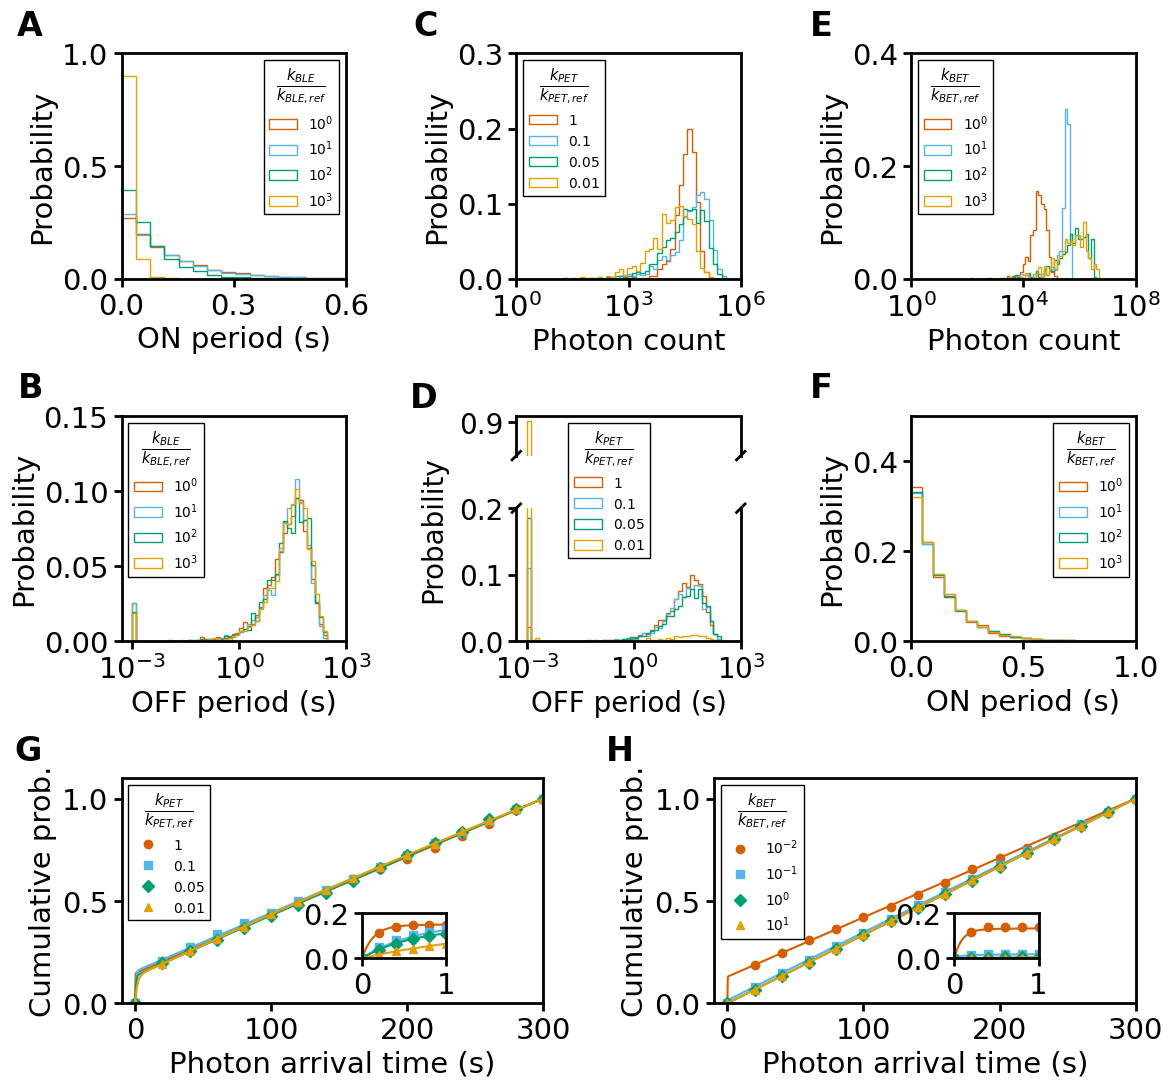

In [19]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

def plot_figure3(ax, labels, data, fit, legendtitle, xlim2, ylim2, spacing2, colors=colors):
    markers = ['o', 's', 'D', '^']
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(ylabel='Cumulative prob.', xlabel='Photon arrival time (s)', legend=True,
                        xlim=[-10, 300], ylim=[0, 1.1])
    for (fingerprint, parameters, label, color, marker) in zip(data, fit, labels, colors, markers):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(data=[fingerprint.index[::spacing1], fingerprint[::spacing1]], label=label, color=color, marker=marker, linestyle='', axes=ax)
        fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], color=color, axes=ax)
    fi.universal_figure(axes=ax, legendargs=dict(title=legendtitle, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), **description)

    inset = ax.inset_axes([0.57, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for (fingerprint, parameters, label, color, marker) in zip(data, fit, labels, colors, markers):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(data=[fingerprint.index[::spacing2], fingerprint[::spacing2]], axes=inset, label=label, color=color, marker=marker, linestyle='')
        fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=inset, color=color)
    inset.set_ylabel('')
    inset.set_xlabel('')


import matplotlib.pyplot as plt
from matplotlib import rcParams
from brokenaxes import brokenaxes

rcParams['axes.linewidth'] = 2
gs = plt.GridSpec(3, 6)
fig = plt.figure(figsize=(12, 11))

ax1 = fig.add_subplot(gs[0, 0:2])
labels1 = [r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$']
legendtitle1 = r'$\frac{k_{BLE}}{k_{BLE,ref}}$'
fi.universal_figure(type_='hist', data=list(reversed(ON_periods_A)), axes=ax1, density=False,
                    label=list(reversed(labels1)), color=list(reversed(colors)), alpha=1, weights=list(reversed(weights_ON_A)),
                    ylabel='Probability', xlabel='ON period (s)', histtype='step', bins=30, xticks=[0, 0.3, 0.6],
                    legend=True, legendargs=dict(title=legendtitle1, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), ylim=[0, 1], xlim=[0, 0.6])

ax2 = fig.add_subplot(gs[1, 0:2])
fi.universal_figure(type_='hist', data=list(reversed(OFF_periods_A)), axes=ax2, density=False, histtype='step',
                    label=list(reversed(labels1)), color=list(reversed(colors)), alpha=1, xscale='log', bins=log_bins_OFF_A,
                    ylabel='Probability', xlabel='OFF period (s)', weights=list(reversed(weights_OFF_A)),
                    legend=True, legendargs=dict(title=legendtitle1, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), ylim=[0, 0.15], xlim=[5e-4, 1e3],
                                                 xticks=[1e-3, 1e0, 1e3])

ax3 = fig.add_subplot(gs[0, 2:4])
labels3 = [r'$1$', r'$0.1$', r'$0.05$', r'$0.01$']
legendtitle3 = r'$\frac{k_{PET}}{k_{PET,ref}}$'
fi.universal_figure(type_='hist', data=list(reversed(total_photons_B)), axes=ax3, density=False, histtype='step',
                    label=list(reversed(labels3)), color=list(reversed(colors)), alpha=1, weights=list(reversed(weights_photons_B)), xscale='log',
                    bins=log_bins_photons_B, ylim=[0, 0.3], xlim=[1e0, 1e6],
                    ylabel='Probability', xlabel='Photon count',
                    legend=True, legendargs=dict(title=legendtitle3, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15))

bax = brokenaxes(ylims=((0, 0.2), (0.85, 0.91)), subplot_spec=gs[1, 2:4], despine=False, d=0.005)
bax.hist(list(reversed(OFF_periods_B)), density=False, histtype='step', label=list(reversed(labels3)), color=list(reversed(colors)),
         alpha=1, bins=log_bins_OFF_B, weights=list(reversed(weights_OFF_B)))
bax.set_xscale('log')
bax.set_ylabel('Probability', fontsize=20, labelpad=50)
bax.set_xlabel('OFF period (s)', fontsize=20, labelpad=35)
bax.legend(title=legendtitle3, framealpha=1, edgecolor='black', fancybox=False, 
           title_fontsize=15, loc='upper left', bbox_to_anchor=(0.2, 0, 1, 1))
bax.tick_params(labelsize=20, width=2, length=6)
bax.set_xlim([5e-4, 1e3])
bax.set_xticks([1e-3, 1e0, 1e3])

ax5 = fig.add_subplot(gs[0, 4:6])
labels5 = [r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$']
legendtitle5 = r'$\frac{k_{BET}}{k_{BET,ref}}$'
fi.universal_figure(type_='hist', data=list(reversed(total_photons_C)), axes=ax5, density=False, histtype='step',
                    label=list(reversed(labels5)), color=list(reversed(colors)), alpha=1, weights=list(reversed(weights_photons_C)), xscale='log',
                    bins=log_bins_photons_C, ylim=[0, 0.4], xlim=[1e0, 1e8], xticks=[1e0, 1e4, 1e8],
                    ylabel='Probability', xlabel='Photon count',
                    legend=True, legendargs=dict(title=legendtitle5, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15))

ax6 = fig.add_subplot(gs[1, 4:6])
fi.universal_figure(type_='hist', data=list(reversed(ON_periods_C)), axes=ax6, density=False,
                    label=list(reversed(labels5)), color=list(reversed(colors)), alpha=1, weights=list(reversed(weights_ON_C)),
                    ylabel='Probability', xlabel='ON period (s)', histtype='step', bins=30,
                    legend=True, legendargs=dict(title=legendtitle5, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), ylim=[0, 0.5], xlim=[0, 1])

ax7 = fig.add_subplot(gs[2, 0:3])
labels7 = [r'$1$', r'$0.1$', r'$0.05$', r'$0.01$']
legendtitle7 = r'$\frac{k_{PET}}{k_{PET,ref}}$'
plot_figure3(ax7, labels7, fingerprints_all_D, parameters_all_fit_cdf_D, legendtitle7, 1, 0.2, 200)

ax8 = fig.add_subplot(gs[2, 3:])
labels8 = [r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
legendtitle8 = r'$\frac{k_{BET}}{k_{BET,ref}}$'
plot_figure3(ax8, labels8, fingerprints_all_E, parameters_all_fit_cdf_E, legendtitle8, 1, 0.2, 200)

axes = fig.get_axes()
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
j = 0
for i, axis in enumerate(axes):
    if i in [4, 5]:
        continue
    offset = -0.35
    if i > 7:
        offset = -0.19
    axis.text(offset, 1.05, letters[j], transform=axis.transAxes, fontsize=24, fontweight='bold', va='bottom', ha='right')
    j += 1
fig.tight_layout()
for handle in bax.diag_handles:
    handle.remove()
bax.draw_diags()

fig.savefig('fingerprint_1f_suppl.png', dpi=300, bbox_inches='tight', pad_inches=0.1)